In [3]:
# import langgraph
# from langgraph.graph import StateGraph,START,END
# from langgraph.prebuilt import ToolNode,tools_condition
from typing import TypedDict,Annotated

In [22]:
class State(TypedDict):
    count : int

In [23]:
def increament(state:State):
    return {"count" : state['count'] + 1}
    

In [24]:
# router function
def check_count(state:State):
    if state["count"] < 3:
        return "continue"
    return "stop"

In [28]:
graph = StateGraph(State)

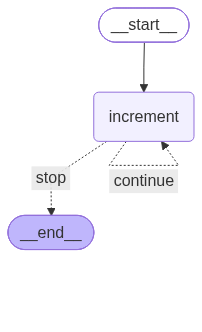

In [29]:
graph.add_node("increment",increament)
graph.add_edge(START,"increment")
graph.add_conditional_edges("increment",check_count,{
    "continue":"increment",
    "stop":END
})



APP = graph.compile()
APP

In [33]:
APP.invoke({"count":-5})

{'count': 3}

In [34]:
class State(TypedDict):
    count : int
    messages : str

In [41]:
def check_count(state:State):
    if state['count'] <= 4:
        return "continue"
    return "stop"


In [42]:
def increament(state:State):
    return {
        "count" : state["count"] + 1,
        "messages" : f"Attempt {state["count"] + 1}"
    }

In [43]:
graph = StateGraph(State)
graph.add_node("increment",increament)

graph.add_edge(START,"increment")
graph.add_conditional_edges("increment",check_count,{
    "continue":"increment",
    "stop":END
})

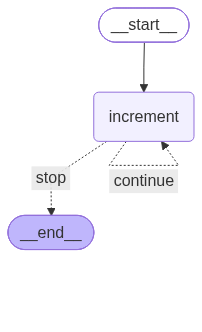

In [44]:
App = graph.compile()
App

In [45]:
App.invoke({"count":4})

{'count': 5, 'messages': 'Attempt 5'}